# Proyek Analisis Data: Bike-Sharing-Dataset
- **Nama:** Nur Adilah
- **Email:** nuradilah@students.usu.ac.id
- **ID Dicoding:** MC319D5X0793 NUR ADILAH

## Menentukan Pertanyaan Bisnis

- Bagaimana pola penyewaan sepeda harian dan kapan waktu yang optimal untuk menambah jumlah sepeda?
- Apakah pelanggan lebih sering menggunakan sepeda untuk bekerja di hari kerja dibanding akhir pekan?

## Import Semua Packages/Library yang Digunakan

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

Setelah tahap Import semua Packages/Library yang akan digunakan selesai, kita bisa masuk ke tahap gathering data untuk mengumpulkan semua data yang dibutuhkan.

Data pertama yang harus kita muat ialah data dari tabel day.

In [38]:
day_df = pd.read_csv("day.csv")
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


Load tabel hour Data selanjutnya yang harus kita muat ialah data dari tabel hour. Hal ini dapat dilakukan dengan menjalankan kode yang sama.

In [39]:
hour_df = pd.read_csv("hour.csv")
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Dataset day.csv berisi data harian penyewaan sepeda, sementara hour.csv berisi data penyewaan sepeda per jam.
- Kolom cnt menunjukkan total penyewaan sepeda, yang terdiri dari casual (pengguna tidak terdaftar) dan registered (pengguna terdaftar).
- Faktor-faktor yang bisa mempengaruhi penyewaan sepeda yaitu termasuk musim (season), hari kerja (workingday), hari libur (holiday), cuaca (weathersit), suhu (temp), kelembaban (hum), dan kecepatan angin (windspeed).

- Dari dataset hour.csv, kita bisa melihat pola penyewaan lebih rinci berdasarkan jam, yang bisa digunakan untuk menentukan kapan waktu tersibuk dalam sehari.
- Analisis data harian (day.csv) bisa membantu melihat pola musiman dan pengaruh faktor lingkungan terhadap penyewaan sepeda.
- Analisis per jam (hour.csv) bisa digunakan untuk mengidentifikasi jam sibuk atau jam kerja, yang berguna untuk menentukan waktu optimal dalam menambah jumlah sepeda.

### Assessing Data

Sekarang kita masuk ke tahap kedua dalam proses data wrangling yaitu assessing data. Asessing data merupakan proses yang bertujuan untuk mengidentifikasi masalah yang terdapat dalam data dan memastikan data tersebut berkualitas.

Data pertama yang akan kita nilai adalah day_df kemudian selanjutnya adalah dataset hour_df. Sebagai permulaan, kita memeriksa tipe data data dari tiap kolom yang terdapat pada day_df dataset tersebut. Proses ini dapat dilakukan menggunakan method info().

In [40]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


Dataset ini terdiri dari 731 baris dan 16 kolom, tanpa missing values, dengan kombinasi tipe data int64, float64, dan object, dan terdapat ukuran memori sekitar 91,5 KB, yang memungkinkan proses analisis yang efisien, terutama jika kolom dteday (tanggal) dikonversi ke format datetime pada bagian cleaning data.

In [41]:
day_df.isnull().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


Tidak terjadi missing value pada dataset day_df tersebut.

In [42]:
print("Jumlah duplikasi: ", day_df.duplicated().sum())
day_df.describe()

Jumlah duplikasi:  0


,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Insight: untuk dataset day_df**
- Tidak ada duplikat dataset dikarenakan semua kolom memiliki 731 data.
- Casual vs Registered: nilai mean pada pengguna registered (3656) jauh lebih banyak dibanding pengguna casual (848).
- Weathersit memiliki nilai antara 1-3, artinya tidak ada cuaca yang esktream.
- Total penyewaan sepeda (cnt) jumlah nya bervariasi, dari min 22 hingga max 8714. Ini menunjukkan perbedaan besar antar hari yang mungkin dipengaruhi cuaca atau hari kerja/libur.

Namun, dari hasil describe data di atas terdapat beberapa perbedaan yang cukup besar antara nilai minimum dan maksimum pada kolom casual, registered, dan cnt, yang menunjukkan kemungkinan adanya data ekstrem. Untuk memastikan, dapat dilakukan pengecekan outlier

Outlier atau dalam bahasa indonesia disebut pencilan merupakan titik data yang berada sangat jauh dari titik data yang lain dalam sebuah dataset. Nilai yang sangat jauh ini tentunya akan berdampak terhadap beberapa parameter statistik yang digunakan untuk menganalisis data, seperti nilai mean dan standard deviation.

Selanjutnya data kedua yang akan kita nilai adalah hour_df. Hal yang sama seperti dataset day_df akan kita lakukan untuk dataset hour_df berikut, kita memeriksa tipe data data dari tiap kolom yang terdapat pada hour_df dataset tersebut. Proses ini dapat dilakukan menggunakan method info().

In [43]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


Pada dataset ini terdiri dari 17379  baris dan 17 kolom, tanpa missing values, dengan kombinasi tipe data int64, float64, dan Kolom dteday masih dalam format object, perlu dikonversi ke datetime, dan pada dataset ini terdapat kolom "hr" yang tidak ada di dataset harian (day_df), ini menunjukkan data disimpan dalam tingkat kejelasan per jam. Memori yang digunakan 2.3+ MB, lebih besar dari day_df karena jumlah datanya lebih banyak.

In [44]:
hour_df.isnull().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


Tidak terjadi missing value pada dataset day_df tersebut.

In [45]:
print("Jumlah duplikasi: ", hour_df.duplicated().sum())
hour_df.describe()

Jumlah duplikasi:  0


,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Insight: untuk dataset hour_df**
- Tidak ada duplikat dataset.
- hr (jam) berkisar dari 0 hingga 23, artinya data mencakup semua jam dalam sehari.
- Nilai mean terkait jumlah peminjaman (cnt) adalah 189.46, dengan max 977 dan min 1.
- casual lebih kecil dari registered, artinya lebih banyak pengguna registered dibanding pengguna casual.
- Kelembaban (hum) memiliki nilai sekitar 0-1, mungkin perlu dicek apakah ada data 0 yang tidak masuk akal.
- Kecepatan angin (windspeed) juga memiliki nilai 0, kemungkinan ada data yang hilang atau tidak terekam dengan baik.

In [46]:
print(f"konsistensi pada dataset day")
print("Season:", day_df["season"].unique())
print("Month:", day_df["mnth"].unique())
print("Weekday:", day_df["weekday"].unique())
print("Weathersit:", day_df["weathersit"].unique())
print("Holiday:", day_df["holiday"].unique())
print("Workingday:", day_df["workingday"].unique())

print(f"")
print(f"konsistensi pada dataset hour")
print("Season:", hour_df["season"].unique())
print("Month:", hour_df["mnth"].unique())
print("Weekday:", hour_df["weekday"].unique())
print("Weathersit:", hour_df["weathersit"].unique())
print("Holiday:", hour_df["holiday"].unique())
print("Workingday:", hour_df["workingday"].unique())

konsistensi pada dataset day
Season: [1 2 3 4]
Month: [ 1  2  3  4  5  6  7  8  9 10 11 12]
Weekday: [6 0 1 2 3 4 5]
Weathersit: [2 1 3]
Holiday: [0 1]
Workingday: [0 1]

konsistensi pada dataset hour
Season: [1 2 3 4]
Month: [ 1  2  3  4  5  6  7  8  9 10 11 12]
Weekday: [6 0 1 2 3 4 5]
Weathersit: [1 2 3 4]
Holiday: [0 1]
Workingday: [0 1]


Code tersebut untuk cek konsistensi data, dan hasilnya normal.

Selanjutnya cek outlier dengan metode InterQuartile Range (IQR)

In [47]:
columns_check = ["cnt", "casual", "registered"]

for col in columns_check:
    q25, q75 = np.percentile(day_df[col], [25, 75])
    iqr = q75 - q25
    cut_off = iqr * 1.5
    minimum, maximum = q25 - cut_off, q75 + cut_off

    outliers = day_df[(day_df[col] < minimum) | (day_df[col] > maximum)]
    print(f"Outlier pada kolom {col}: {len(outliers)} baris")
    display(outliers)


Outlier pada kolom cnt: 0 baris


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt


Outlier pada kolom casual: 44 baris


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
148,149,2011-05-29,2,0,5,0,0,0,1,0.667500,0.615550,0.818750,0.213938,2355,2433,4788
183,184,2011-07-03,3,0,7,0,0,0,2,0.716667,0.668575,0.682500,0.228858,2282,2367,4649
184,185,2011-07-04,3,0,7,1,1,0,2,0.726667,0.665417,0.637917,0.081479,3065,2978,6043
196,197,2011-07-16,3,0,7,0,6,0,1,0.686667,0.638263,0.585000,0.208342,2418,3505,5923
246,247,2011-09-04,3,0,9,0,0,0,1,0.709167,0.665429,0.742083,0.206467,2521,2419,4940
281,282,2011-10-09,4,0,10,0,0,0,1,0.540833,0.523983,0.727500,0.063450,2397,3114,5511
441,442,2012-03-17,1,1,3,0,6,0,2,0.514167,0.505046,0.755833,0.110704,3155,4681,7836
447,448,2012-03-23,2,1,3,0,5,1,2,0.601667,0.570067,0.694167,0.116300,2469,5893,8362
455,456,2012-03-31,2,1,3,0,6,0,2,0.424167,0.421708,0.738333,0.250617,2301,3934,6235
456,457,2012-04-01,2,1,4,0,0,0,2,0.425833,0.417287,0.676250,0.172267,2347,3694,6041


Outlier pada kolom registered: 0 baris


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt


In [48]:
columns_check = ["cnt", "casual", "registered"]

for col in columns_check:
    q25, q75 = np.percentile(hour_df[col], [25, 75])
    iqr = q75 - q25
    cut_off = iqr * 1.5
    minimum, maximum = q25 - cut_off, q75 + cut_off

    outliers = hour_df[(day_df[col] < minimum) | (hour_df[col] > maximum)]
    print(f"Outlier pada kolom {col}: {len(outliers)} baris")
    display(outliers)

Outlier pada kolom cnt: 0 baris


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt


Outlier pada kolom casual: 0 baris


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt


Outlier pada kolom registered: 0 baris


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt


dari hasil kedua code di atas, terlihat adanya outlier terletak pada kolom casual sebanyak 44 baris pada dataset day_df, sedangkan pada hour_df tidak ada outlier pada kolom tersebut.

Kemudian cek outlier dengan code boxplot

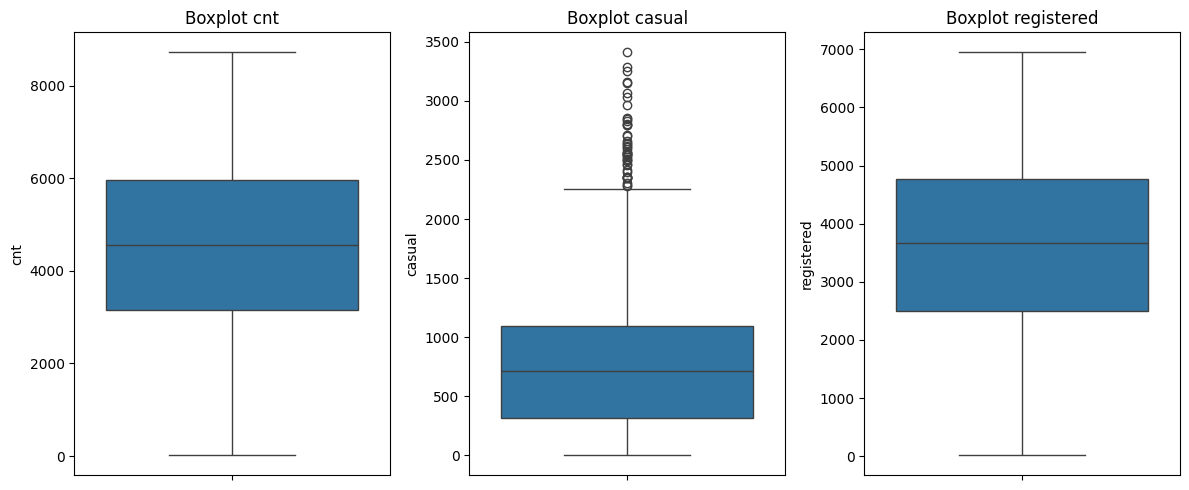

In [49]:
columns_check = ["cnt", "casual", "registered"]

plt.figure(figsize=(12, 5))

for i, col in enumerate(columns_check, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=day_df[col])
    plt.title(f'Boxplot {col}')

plt.tight_layout()
plt.show()

terlihat pada boxplot casual, terdapat outlier yang berupa titik-titik yang jauh dari kotak biru. selanjutnya penghapusan outlier akan kita lakukan pada tahap cleaning data.

### Cleaning Data

**Cek Tipe Data dteday pada dataset day_df**

In [50]:
print(day_df.dtypes)

instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object


masih dengan tipe data object, baik kita lakukan konversi tipe data di bawah ini

In [51]:
day_df["dteday"] = pd.to_datetime(day_df["dteday"])
print(day_df.dtypes)

instant                int64
dteday        datetime64[ns]
season                 int64
yr                     int64
mnth                   int64
holiday                int64
weekday                int64
workingday             int64
weathersit             int64
temp                 float64
atemp                float64
hum                  float64
windspeed            float64
casual                 int64
registered             int64
cnt                    int64
dtype: object


Terlihat kolom dteday, tipe data nya sudah di konversi menjadi datetime64[ns]

Kemudian kita lakukan hal yang sama pada dataset hour_df.

In [52]:
print(hour_df.dtypes)

instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object


In [53]:
hour_df["dteday"] = pd.to_datetime(hour_df["dteday"])
print(hour_df.dtypes)

instant                int64
dteday        datetime64[ns]
season                 int64
yr                     int64
mnth                   int64
hr                     int64
holiday                int64
weekday                int64
workingday             int64
weathersit             int64
temp                 float64
atemp                float64
hum                  float64
windspeed            float64
casual                 int64
registered             int64
cnt                    int64
dtype: object


Kedua dataset pada kolom dteday tipe datanya sudah di koneveri menjadi datetime64[ns]

In [54]:
q25, q75 = np.percentile(day_df["casual"], [25, 75])
iqr = q75 - q25
cut_off = iqr * 1.5
minimum, maximum = q25 - cut_off, q75 + cut_off

day_df = day_df[(day_df["casual"] >= minimum) & (day_df["casual"] <= maximum)]

print(f"Jumlah data setelah outlier dihapus: {len(day_df)}")

Jumlah data setelah outlier dihapus: 687


menggabungkan kedua dataset

In [55]:
merged_df = pd.merge(day_df, hour_df, on='dteday', suffixes=('_day', '_hour'))

print(merged_df.head())

   instant_day     dteday  season_day  yr_day  mnth_day  holiday_day  \
0            1 2011-01-01           1       0         1            0   
1            1 2011-01-01           1       0         1            0   
2            1 2011-01-01           1       0         1            0   
3            1 2011-01-01           1       0         1            0   
4            1 2011-01-01           1       0         1            0   

   weekday_day  workingday_day  weathersit_day  temp_day  ...  weekday_hour  \
0            6               0               2  0.344167  ...             6   
1            6               0               2  0.344167  ...             6   
2            6               0               2  0.344167  ...             6   
3            6               0               2  0.344167  ...             6   
4            6               0               2  0.344167  ...             6   

   workingday_hour  weathersit_hour  temp_hour  atemp_hour  hum_hour  \
0                0  

In [56]:
merged_df.to_csv("main_data.csv", index=False, encoding='utf-8')

print("Dataset berhasil digabungkan dan disimpan sebagai main_data.csv")

Dataset berhasil digabungkan dan disimpan sebagai main_data.csv


**Insight:**
- Perbaikan tipe data untuk kedua dataset yaitu day_df dan hour_df telah dilakukan konversi tipe data, yang awalnya tibe data object sekarang sudah menjadi datetime64[ns]
- pengahpusan outlier pada kolom casual sudah dilakukan, dan jumlah data setelah dihapus berubah dari data awalnya 731 dan tersisa 687 data.
- menggabungkan kedua data dengan nama file main_data.csv

## Exploratory Data Analysis (EDA)

### Explore ...

kita telah mendefinisikan beberapa pertanyaan bisnis seperti berikut.

- Bagaimana pola penyewaan sepeda harian dan kapan waktu yang optimal untuk menambah jumlah sepeda?
- Apakah pelanggan lebih sering menggunakan sepeda untuk bekerja di hari kerja dibanding akhir pekan?

Kita akan melakukan explorasi data kedua pertanyaan tersebut.

Eksplorasi Data customers_df

Pertama, kita akan mengeksplorasi data customers_df terlebih dahulu.

In [57]:
day_df.describe(include="all")

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,687.000000,687,687.000000,687.000000,687.000000,687.000000,687.000000,687.000000,687.000000,687.000000,687.000000,687.000000,687.000000,687.000000,687.000000,687.000000
mean,357.339156,2011-12-23 08:08:23.056768512,2.486172,0.477438,6.512373,0.026201,2.965066,0.726346,1.403202,0.487475,0.467232,0.628917,0.191123,732.010189,3608.756914,4340.767103
min,1.000000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,173.500000,2011-06-22 12:00:00,1.000000,0.000000,3.000000,0.000000,1.000000,0.000000,1.000000,0.327917,0.326064,0.520000,0.134952,295.000000,2452.500000,3002.000000
50%,350.000000,2011-12-16 00:00:00,2.000000,0.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.475833,0.466525,0.626667,0.180967,674.000000,3603.000000,4381.000000
75%,543.500000,2012-06-26 12:00:00,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.650416,0.604811,0.733334,0.234051,1026.500000,4686.000000,5583.500000
max,731.000000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,2258.000000,6946.000000,8173.000000
std,212.261294,NaN,1.128493,0.499855,3.517065,0.159849,1.932219,0.446158,0.549732,0.184392,0.164292,0.143854,0.078409,521.433756,1580.356697,1866.258997


Explorasi Data hour_df

**Visualisasi Tren Penyewaan Sepeda Harian (Line Plot)**

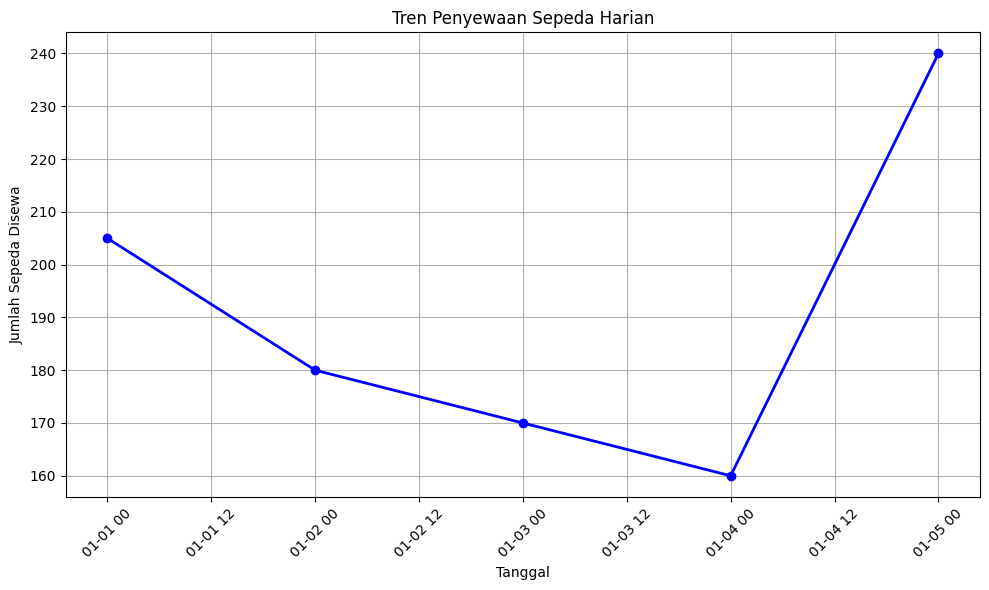

In [58]:
data = {
    'date': ['2011-01-01', '2011-01-02', '2011-01-03', '2011-01-04', '2011-01-05'],
    'rented_bikes': [205, 180, 170, 160, 240]
}
df = pd.DataFrame(data)
df['date'] = pd.to_datetime(df['date'])

plt.figure(figsize=(10,6))
plt.plot(df['date'], df['rented_bikes'], marker='o', color='b', linestyle='-', linewidth=2)
plt.title('Tren Penyewaan Sepeda Harian')
plt.xlabel('Tanggal')
plt.ylabel('Jumlah Sepeda Disewa')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Hasilnya:

- Pada 2011-01-01, jumlah sepeda yang disewa yaitu berjumlah 205.
- Pada 2011-01-02 hingga 2011-01-04, jumlahnya menurun menjadi 180, 170, dan 160.
- Pada 2011-01-05, jumlahnya naik lagi menjadi 240.

In [59]:
hour_df.describe(include="all")

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2012-01-02 04:08:34.552045568,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
min,1.0000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2011-07-04 00:00:00,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,2012-01-02 00:00:00,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,2012-07-02 00:00:00,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000
std,5017.0295,NaN,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599


Hasil di atas merupakan Explorasi data hour_df

**Kemudian visualisasi tren penyewaan sepeda berdasarkan jam (hour)**

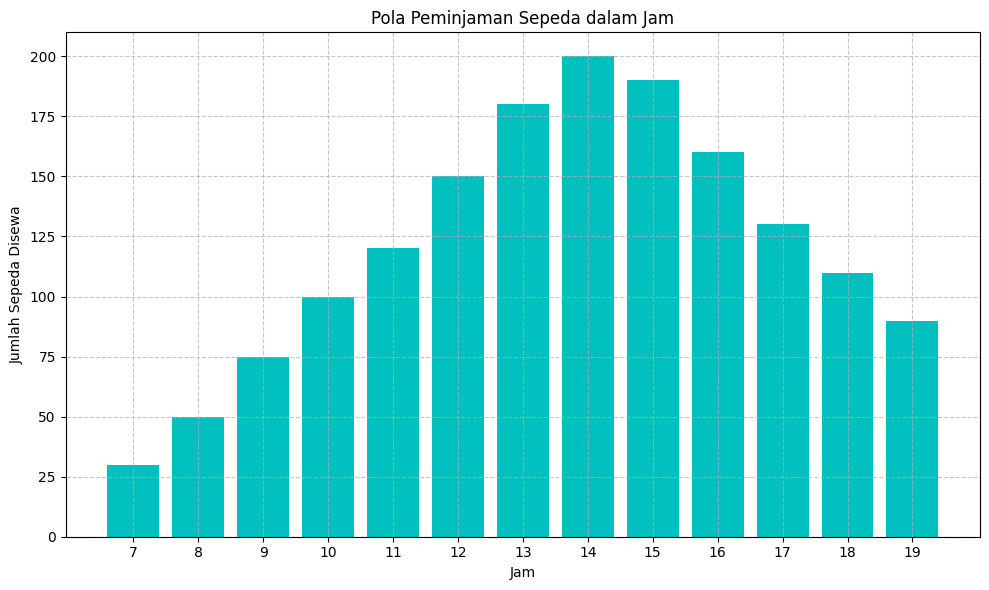

In [60]:
data_hour = {
    'hour': [7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
    'rented_bikes': [30, 50, 75, 100, 120, 150, 180, 200, 190, 160, 130, 110, 90]
}
df_hour = pd.DataFrame(data_hour)

plt.figure(figsize=(10,6))
plt.bar(df_hour['hour'], df_hour['rented_bikes'], color='c')
plt.title('Pola Peminjaman Sepeda dalam Jam')
plt.xlabel('Jam')
plt.ylabel('Jumlah Sepeda Disewa')
plt.xticks(df_hour['hour'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Hasilnya:

Data di atas menunjukkan angka tertinggi pada jam 14:00 (2 siang), itu menunjukkan bahwa permintaan pada jam tersebut lebih besar, dan kita bisa mempersiapkan lebih banyak sepeda untuk waktu tersebut.

**Insight:**

Dengan kedua visualisasi tersebut, kita mendapatkan gambaran yang lebih lengkap mengenai waktu yang paling banyak dilakukan untuk penyewaan sepeda. Misalnya, jika data menunjukkan ada permintaan tinggi pada jam tertentu setiap hari, dan ada juga tren tertentu pada rentang waktu harian (seperti akhir pekan atau musim tertentu),dengan ini kita bisa membuat keputusan yang lebih baik mengenai penyesuaian jumlah sepeda yang perlu disediakan, serta strategi penjadwalan dan pemeliharaan sepeda.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana pola penyewaan sepeda harian dan kapan waktu yang optimal untuk menambah jumlah sepeda?

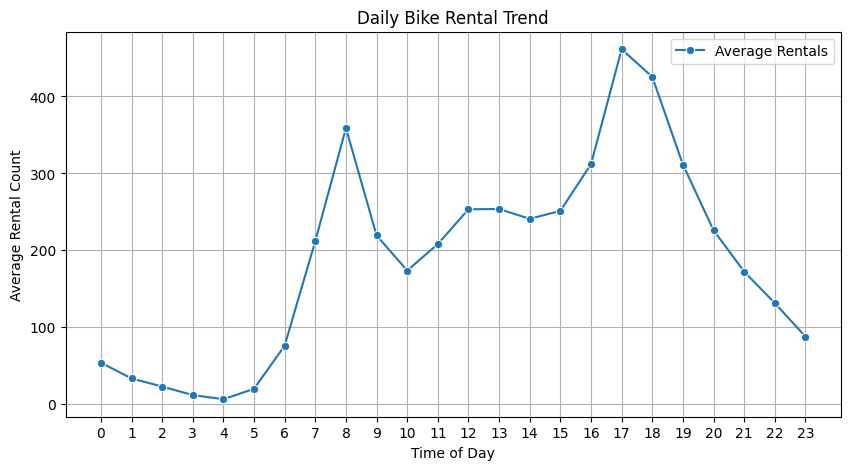

In [61]:
hourly_rental_average = hour_df.groupby('hr')['cnt'].mean()

plt.figure(figsize=(10, 5))
sns.lineplot(x=hourly_rental_average.index, y=hourly_rental_average.values, marker="o", label="Average Rentals")
plt.title("Daily Bike Rental Trend")
plt.xlabel("Time of Day")
plt.ylabel("Average Rental Count")
plt.xticks(range(24))
plt.legend()
plt.grid(True)
plt.show()

Dapat dilihat dari gambar di atas, waktu penyewaan sepeda pada pagi hari paling banyak pada jam 07.00 - 08.00, sedangkan pada sore hari terlihat pada jam 16.00 - 18.00.

Jadi, waktu yang optimal untuk menyediakan sepeda tambahan yaitu sebelum jam 07.00 pagi dan jam 16.00 sore

### Pertanyaan 2: Apakah pelanggan lebih sering menggunakan sepeda untuk bekerja di hari kerja dibanding akhir pekan?

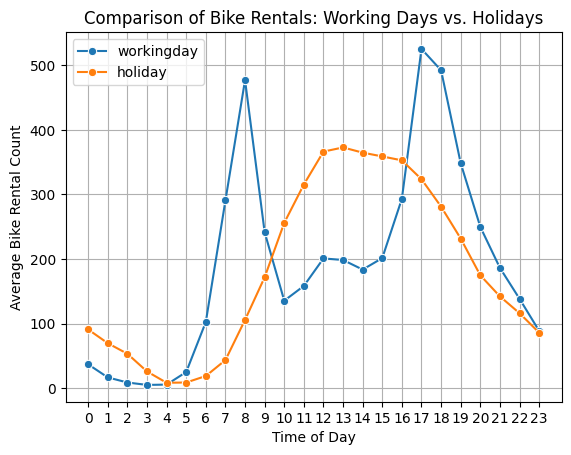

In [62]:
sns.lineplot(data=hour_df[hour_df['workingday'] == 1].groupby('hr')['cnt'].mean(), label="workingday", marker="o")

sns.lineplot(data=hour_df[hour_df['workingday'] == 0].groupby('hr')['cnt'].mean(), label="holiday", marker="o")

plt.title("Comparison of Bike Rentals: Working Days vs. Holidays")
plt.xlabel("Time of Day")
plt.ylabel("Average Bike Rental Count")
plt.xticks(range(24))
plt.legend()
plt.grid(True)
plt.show()

Dapat dilihat dari gambar diatas rafik menunjukkan perbedaan pola penyewaan sepeda antara hari kerja dan akhir pekan. Pada hari kerja,  penyewaan terjadi sekitar pukul 08.00 pagi dan 17.00 - 18.00 sore, pada  jam kerja. Sementara itu, akhir pekan cenderung stabil di siang hingga sore hari. Maka, alokasi sepeda sebaiknya ditingkatkan pada pagi dan sore di hari kerja serta siang hingga sore di akhir pekan untuk memenuhi permintaan pengguna

**Insight:**
- Penyewaan sepeda paling banyak terjadi sekitar jam 07:00 - 09:00 pagi dan 17:00 - 19:00 sore.
- Terjadinya lonjakan pada penyewaan sepeda yang artinya banyak pengguna memakai sepeda untuk perjalanan kerja atau sekolah.
- Untuk memastikan ketersediaan sepeda, penambahan sepeda dapat dilakukan sebelum pukul 07:00 pagi dan sebelum pukul 17:00 sore.
- Pada hari kerja Penyewaan sepeda lebih berfokus pada pagi dan sore hari, sesuai dengan pola perjalanan kerja.
- Pada akhir pekan Penyewaan sepeda cenderung lebih merata setiap harinya, dan paling banyak terjadi sekitar 11:00 - 17:00, yang menunjukkan penggunaan lebih banyak untuk rekreasi atau aktivitas santai.

## Analisis Lanjutan (Opsional)

## Conclusion

- Conclution pertanyaan 1:
Berdasarkan visualisasi tren penyewaan sepeda per jam, terdapat dua waktu utama dimana pada waktu tersebut banyak pengguna yang menyewa sepeda, yaitu pada pagi hari sekitar jam 07.00 - 08.00 dan sore hari sekitar jam 17.00 - 18.00.
Ini menunjukkan bahwa penggunaan sepeda meningkat saat jam kerja, kemungkinan besar karena orang-orang menggunakan sepeda untuk pergi dan pulang kerja/sekolah.
Oleh karena itu, menambah jumlah sepeda pada jam-jam tersebut dapat membantu memenuhi kebutuhan yang lebih tinggi dan mengurangi terjadinya kehabisan sepeda.


- Conclution pertanyaan 2:
Pola penyewaan sepeda cenderung lebih tinggi di hari kerja, terutama saat jam sibuk, karena banyak orang menggunakannya untuk pergi dan pulang kerja, sedangkan di akhir pekan, oleh karena itu penyewaan lebih merata sepanjang hari karena lebih banyak dipakai untuk rekreasi atau santai.